In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('./src')

Coordinates:
[[99.65661218 14.83912113]
 [72.5846948  51.3321894 ]
 [53.33980963 33.53511841]
 [46.19934633 25.93475257]]

Distance Matrix:
[[ 0.         45.43822996 49.94783793 54.59663277]
 [45.43822996  0.         26.21261797 36.62262158]
 [49.94783793 26.21261797  0.         10.428412  ]
 [54.59663277 36.62262158 10.428412    0.        ]]


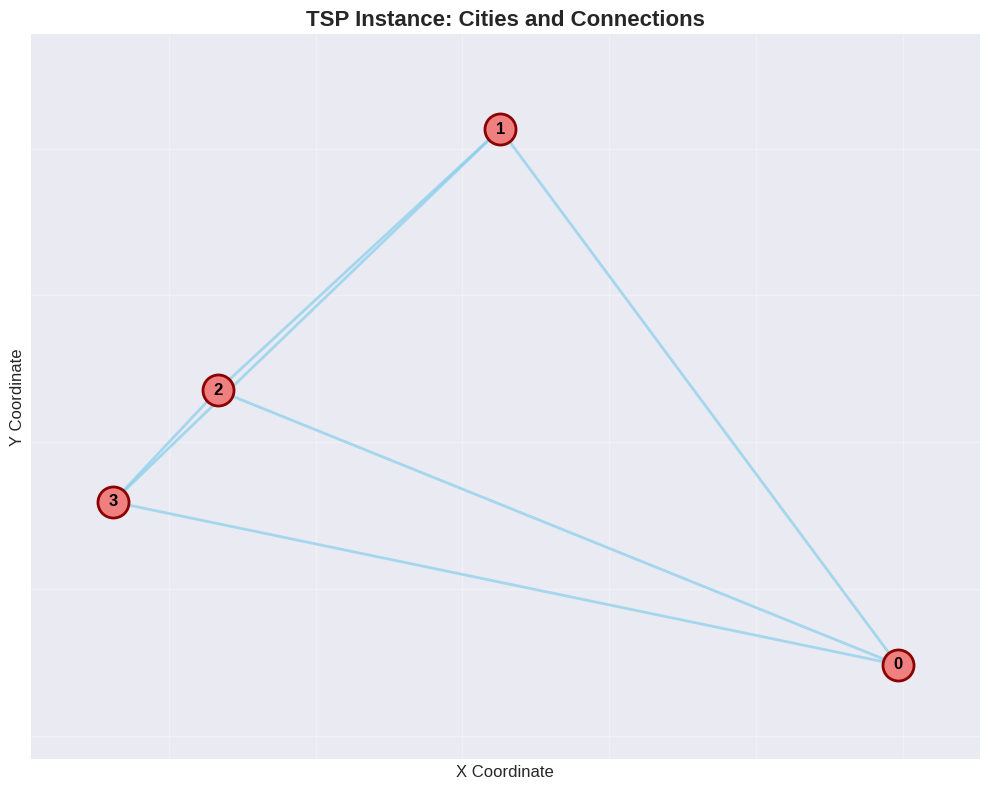

In [2]:
from tsp import TSPInstance

n_cities = 4  # Change this to the desired number of cities
tsp_instance = TSPInstance(n_cities)
print("Coordinates:")
print(tsp_instance.coords)
print("\nDistance Matrix:")
print(tsp_instance.dist_matrix)

# Plot the instance
tsp_instance.plot_tsp_instance()

Asymmetric TSP Coordinates:
[[77.34883542 27.63476017]
 [70.18351214 23.97754101]
 [17.36072349 93.75842102]
 [42.9399968  29.4140421 ]]

Asymmetric Distance Matrix:
[[  0.           8.31060723  69.46301381  35.21195335]
 [  9.19107195   0.          78.65612031  37.06678316]
 [121.82124509  93.24351317   0.          54.00185597]
 [ 29.16115685  31.48411906  72.41229554   0.        ]]


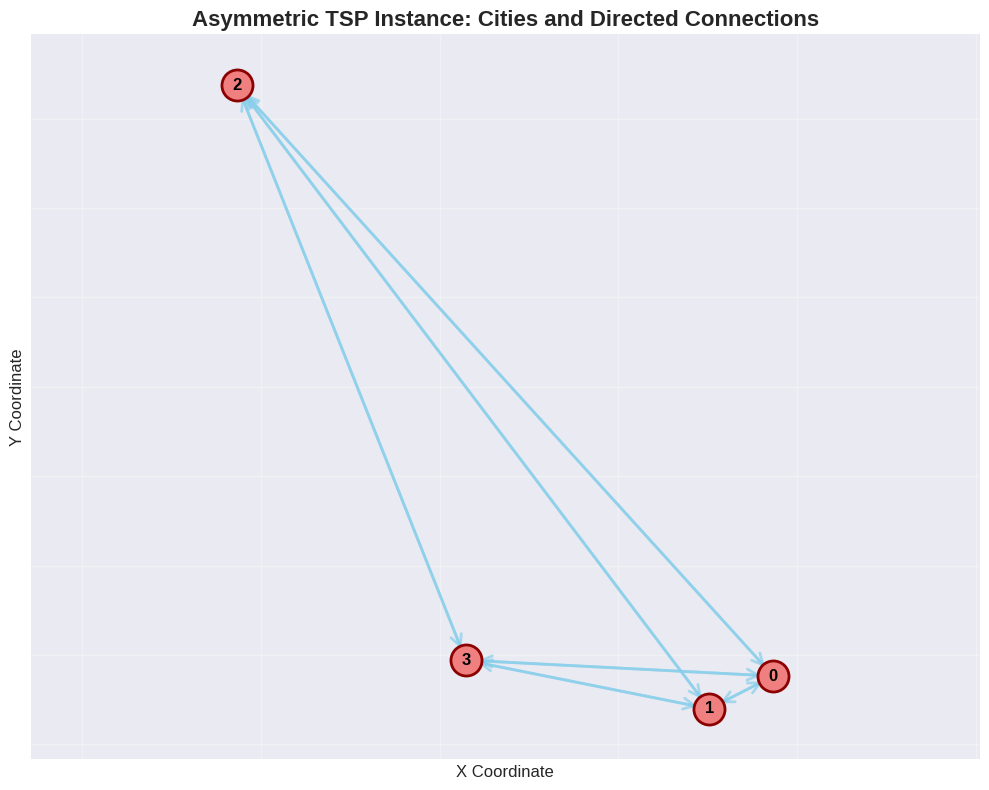

In [3]:
# Example of Asymmetric TSP
n_cities = 4
asymmetric_tsp = TSPInstance(n_cities, asymmetric=True)
print("Asymmetric TSP Coordinates:")
print(asymmetric_tsp.coords)
print("\nAsymmetric Distance Matrix:")
print(asymmetric_tsp.dist_matrix)

# Plot the asymmetric instance
asymmetric_tsp.plot_tsp_instance()

In [4]:
from bloch_sphere_encoding import BlochSphereEncoder

encoder = BlochSphereEncoder(tsp_instance)
bloch_tsp = encoder.get_encoded_instance()

bloch_tsp.plot_all_cities_on_bloch_sphere()

In [5]:
bloch_tsp.plot_all_states_on_bloch_sphere()

In [ ]:
list = bloch_tsp.travel_operators

for i in range(len(list)):
    for j in range(len(list[i])):
        if list[i][j] is not None:
            print(f"Operator from city {list[i][j].from_city} to city {list[i][j].to_city}:")
            print(f"  Up state: {list[i][j].up}")
            print(f"  Down state: {list[i][j].down}")
            print(f"  Cost: {list[i][j].cost}\n")
        else:
            
            print(list[i][j])

None
Operator from city 0 to city 1:
  Up state: Operator([[0.70097884+0.j, 0.70097884+0.j],
          [0.09289058+0.j, 0.09289058+0.j]],
         input_dims=(2,), output_dims=(2,))
  Down state: Operator([[7.00978845e-01+0.j        , 9.28905767e-02+0.j        ],
          [4.29225749e-17+0.70097884j, 5.68790737e-18+0.09289058j]],
         input_dims=(2,), output_dims=(2,))
  Cost: 1.3073004891012563

Operator from city 0 to city 2:
  Up state: Operator([[0.70552618+0.j, 0.70552618+0.j],
          [0.04725259+0.j, 0.04725259+0.j]],
         input_dims=(2,), output_dims=(2,))
  Down state: Operator([[ 0.70552618+0.00000000e+00j,  0.04725259+0.00000000e+00j],
          [-0.70552618+8.64020380e-17j, -0.04725259+5.78677364e-18j]],
         input_dims=(2,), output_dims=(2,))
  Cost: 1.437046139434534

Operator from city 0 to city 3:
  Up state: Operator([[0.70710678+0.j, 0.70710678+0.j],
          [0.        +0.j, 0.        +0.j]],
         input_dims=(2,), output_dims=(2,))
  Down state: O

In [9]:
initial_state = bloch_tsp.get_city_state(0)

expected_final_state = bloch_tsp.get_city_state(2)

travel_operator = bloch_tsp.travel_operators[0][2]
computed_final_state = initial_state.evolve(travel_operator.up).evolve(travel_operator.down)

print("Initial State (City 0):", initial_state)
print("Expected Final State (City 2):", expected_final_state)
print("Computed Final State after applying travel operator:", computed_final_state)
print("States match:", np.allclose(expected_final_state.data, computed_final_state.data))

Initial State (City 0): Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
Expected Final State (City 2): Statevector([ 0.70710678+0.00000000e+00j, -0.70710678+8.65956056e-17j],
            dims=(2,))
Computed Final State after applying travel operator: Statevector([ 0.70710678+0.00000000e+00j, -0.70710678+8.65956056e-17j],
            dims=(2,))
States match: True
